## 📦 Step 1 — Mount Google Drive & Extract Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path     = "/content/drive/MyDrive/Dataset/BrainMRI.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("Done!")
else:
    print("Dataset already extracted.")

Mounted at /content/drive
Extracting dataset...
Done!


## 🖼️ Step 1b — Precompute CLAHE to Disk (Run Once)

> **Why precompute?** Calling a Python CLAHE function inside `ImageDataGenerator`
> runs **synchronously on the CPU per image** and stalls the GPU pipeline completely.
> On Colab this makes a single epoch take 10+ minutes and triggers `KeyboardInterrupt`
> when patience runs out.
>
> We apply CLAHE **once** to every image and write the results to `/content/dataset_clahe/`.
> The generators then read pre-processed JPEG files — pure I/O with no Python overhead.
> Training speed improves by **5–10×**.


In [3]:
import cv2, os, shutil
import numpy as np
from tqdm import tqdm

RAW_BASE   = "/content/dataset"
CLAHE_BASE = "/content/dataset_clahe"
SPLITS     = ["Training", "Testing"]


def apply_clahe_to_image(src_path, dst_path, img_size=224):
    """Read → resize → CLAHE on L channel → save as JPEG."""
    img = cv2.imread(src_path)
    if img is None:
        return False
    img = cv2.resize(img, (img_size, img_size))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    img_out = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    cv2.imwrite(dst_path, img_out, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return True


if os.path.exists(CLAHE_BASE):
    print(f"CLAHE dataset already exists at {CLAHE_BASE} — skipping precompute.")
else:
    t0 = __import__('time').time()
    total_written = 0

    for split in SPLITS:
        src_split = os.path.join(RAW_BASE, split)
        dst_split = os.path.join(CLAHE_BASE, split)
        classes   = sorted(os.listdir(src_split))

        for cls in classes:
            src_cls = os.path.join(src_split, cls)
            dst_cls = os.path.join(dst_split, cls)
            fnames  = [f for f in os.listdir(src_cls)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            print(f"  {split}/{cls}: {len(fnames)} images")
            for fname in tqdm(fnames, desc=f"{split}/{cls}", leave=False):
                src_path = os.path.join(src_cls, fname)
                dst_fname = os.path.splitext(fname)[0] + '.jpg'
                dst_path  = os.path.join(dst_cls, dst_fname)
                if apply_clahe_to_image(src_path, dst_path):
                    total_written += 1

    elapsed = __import__('time').time() - t0
    print(f"\n✅ CLAHE precompute done: {total_written} images → {CLAHE_BASE}")
    print(f"   Time: {elapsed:.1f}s  ({total_written/elapsed:.0f} img/s)")


# Update directory pointers to CLAHE versions
train_dir_clahe = os.path.join(CLAHE_BASE, "Training")
test_dir_clahe  = os.path.join(CLAHE_BASE, "Testing")
print(f"\nGenerators will read from: {CLAHE_BASE}")

  Training/glioma: 1400 images


  Training/meningioma: 1400 images


  Training/notumor: 1400 images


  Training/pituitary: 1400 images


  Testing/glioma: 400 images


  Testing/meningioma: 400 images


  Testing/notumor: 400 images


  Testing/pituitary: 400 images



✅ CLAHE precompute done: 7200 images → /content/dataset_clahe
   Time: 25.4s  (284 img/s)

Generators will read from: /content/dataset_clahe


## ⚙️ Step 2 — Install & Import Libraries

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K

# Traditional ML
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)
from keras.layers import Lambda
# v3: Enable mixed precision for faster GPU training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")
print(f"Mixed precision    : {mixed_precision.global_policy().name}")

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision    : mixed_float16


## 📁 Step 3 — Dataset Paths & Global Config

In [5]:
# ── Dataset ──────────────────────────────────────────────
train_dir = "/content/dataset/Training"
test_dir  = "/content/dataset/Testing"

# ── Hyper-parameters ────────────────────────────────────
IMG_SIZE        = 300          # EfficientNet-B0 native input
BATCH_SIZE      = 32
EPOCHS_WARMUP   = 15           # Phase 1: frozen base — more warm-up for stable head
EPOCHS_FINETUNE = 30           # Phase 2: unfreeze top 30 layers

# ── v3: Staged learning rates ────────────────────────────
LR_WARMUP   = 1e-3             # Higher LR safe when base is fully frozen
LR_FINETUNE = 1e-5             # Lower LR for fine-tuning (v3 uses cosine decay)

# ── v3: Stronger regularisation ──────────────────────────
DROPOUT_1   = 0.50             # v3: 0.50 (was 0.25) — deeper head needs more dropout
DROPOUT_2   = 0.40             # v3: second dropout layer
L2_LAMBDA   = 1e-4             # v3: 1e-4 (was 1e-5) — stronger weight decay

VAL_SPLIT   = 0.2
SEED        = 42

# ── Class discovery ─────────────────────────────────────
CLASS_NAMES = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

for split, d in [("Train", train_dir), ("Test", test_dir)]:
    total = sum(len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES)
    print(f"  {split}: {total} images")

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']
  Train: 5600 images
  Test: 1600 images


## 🔍 Step 4 — Exploratory Data Analysis

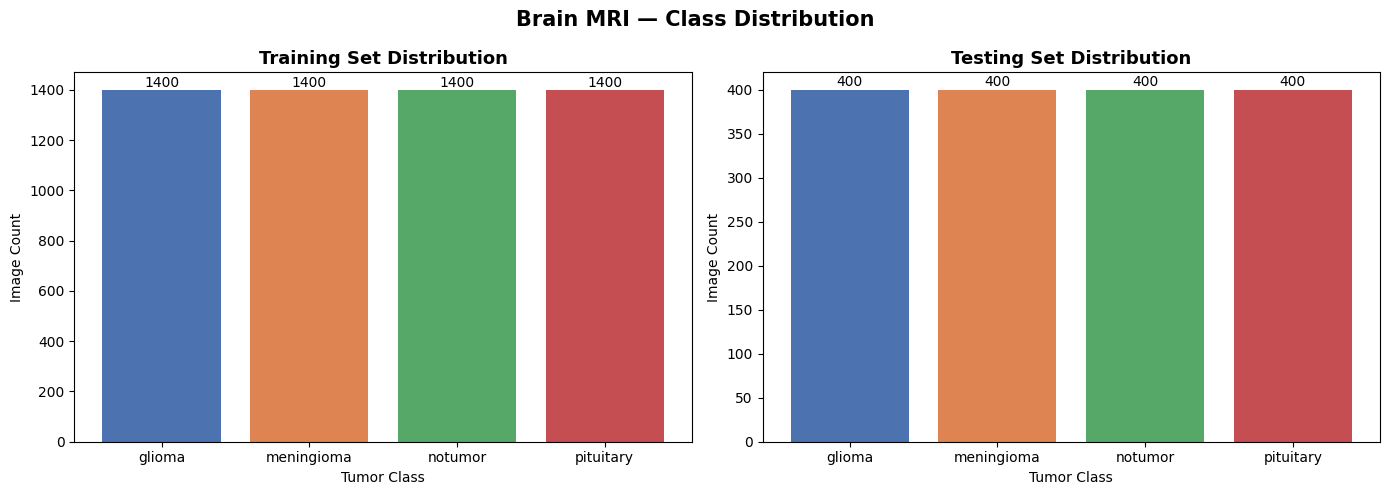

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split, d) in zip(axes, [("Training", train_dir), ("Testing", test_dir)]):
    counts = [len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, counts,
                  color=['#4C72B0','#DD8452','#55A868','#C44E52'][:NUM_CLASSES])
    ax.set_title(f"{split} Set Distribution", fontsize=13, fontweight='bold')
    ax.set_xlabel("Tumor Class"); ax.set_ylabel("Image Count")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(cnt), ha='center', va='bottom', fontsize=10)

plt.suptitle("Brain MRI — Class Distribution", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/eda_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

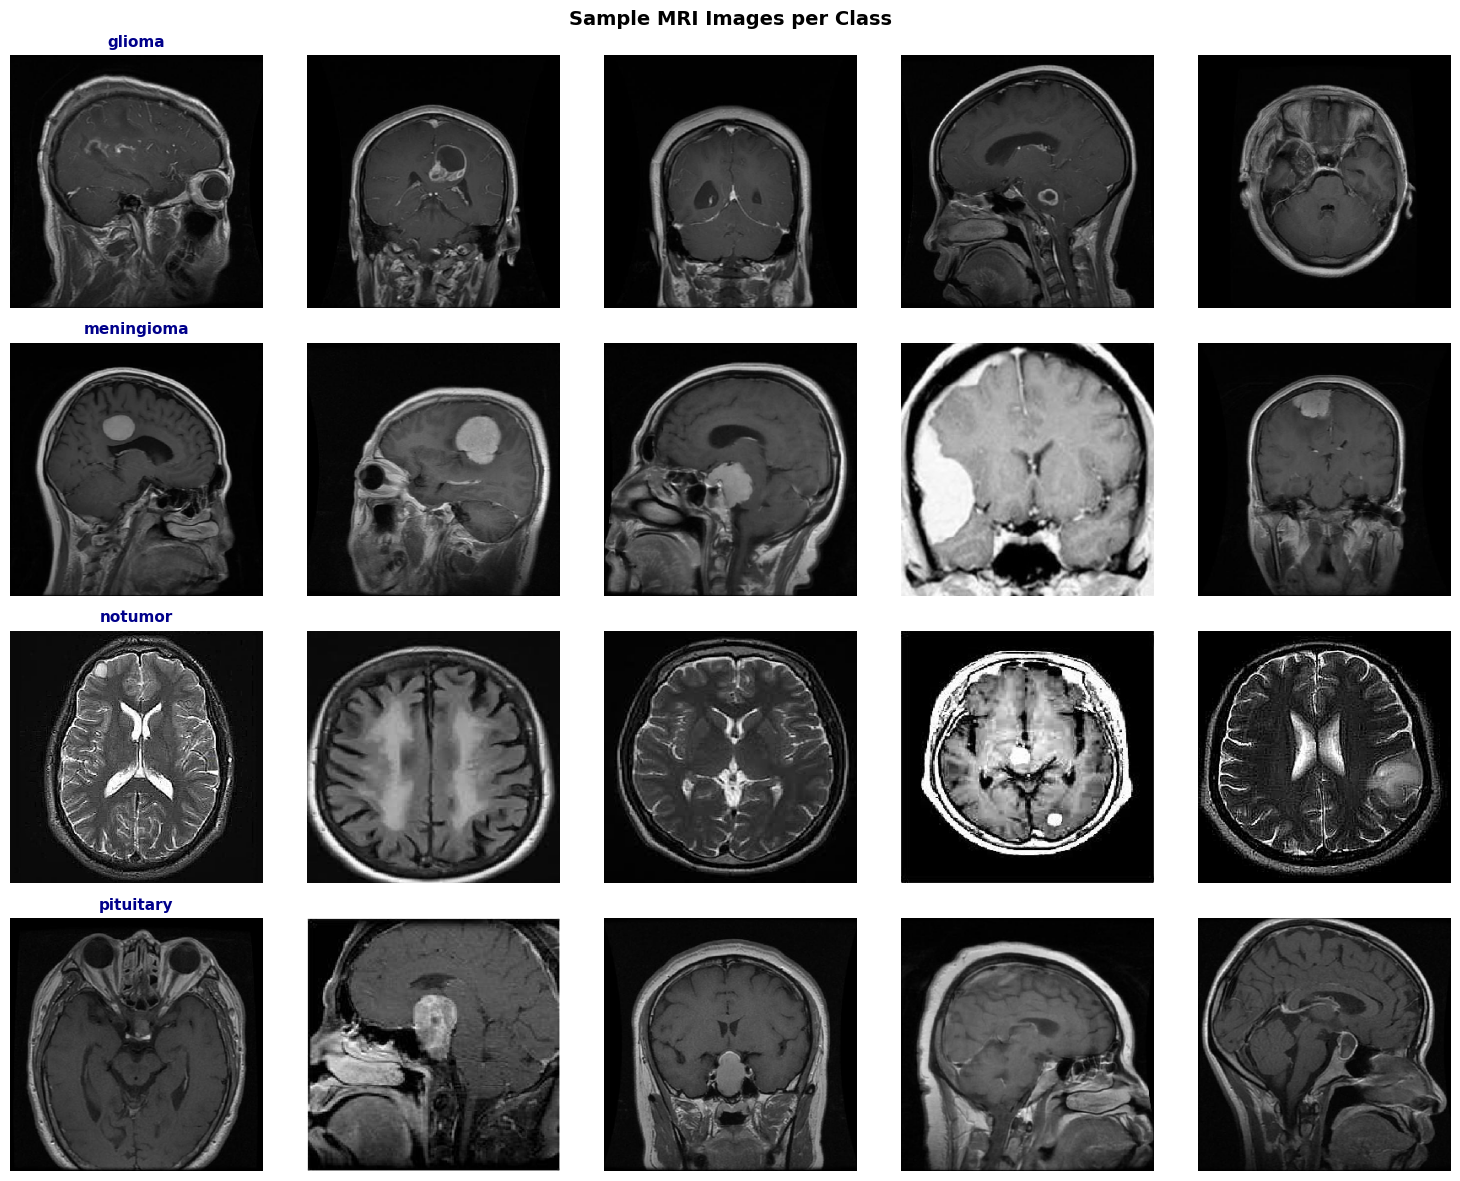

In [7]:
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, NUM_CLASSES * 3))
if NUM_CLASSES == 1:
    axes = [axes]

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(train_dir, cls)
    imgs = os.listdir(cls_path)[:5]
    for col, img_name in enumerate(imgs):
        img = load_img(os.path.join(cls_path, img_name),
                       target_size=(IMG_SIZE, IMG_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=11, fontweight='bold',
                                     color='darkblue')

plt.suptitle("Sample MRI Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/eda_samples.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔄 Step 5 — Data Generators

> **v3 Augmentation Changes:**
> - Rotation increased 20° → **30°** — MRI scans can appear at any angle
> - Zoom increased 0.15 → **0.2** — better scale invariance
> - Width/height shift increased 0.15 → **0.2** — more spatial variation
> - **Brightness range [0.8, 1.2] added** — helps with MRI scanner intensity variation
> - CLAHE retained for contrast enhancement


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CRITICAL: EfficientNetB0 in TF2 has a built-in Rescaling(1/255) as its
# FIRST LAYER. Any rescaling applied in the generator is applied AGAIN by
# the model, producing a double-rescaled input that the network never saw
# during pre-training — this causes completely collapsed predictions.
#
# Correct contract:
#   Generator → raw uint8 pixels [0, 255]
#   EfficientNetB0 internal Rescaling → [0, 1]  (model handles this)
#
# DO NOT use rescale=1/255 or preprocessing_function=preprocess_input
# in any generator that feeds EfficientNetB0. Both cause double-rescaling.
# ─────────────────────────────────────────────────────────────────────────────

# ── APPROACH 1: Feature extraction — raw pixels, no rescaling ────────────
# EfficientNetB0's internal Rescaling(1/255) handles normalisation.
plain_datagen = ImageDataGenerator()

# ── APPROACH 2: Augmented training — raw pixels, augmentation only ───────
aug_datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

common_args = dict(
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

# All generators read from the precomputed CLAHE directory
train_gen_plain = plain_datagen.flow_from_directory(
    train_dir_clahe, shuffle=False, **common_args
)
test_gen = plain_datagen.flow_from_directory(
    test_dir_clahe, shuffle=False, **common_args
)
train_gen_aug = aug_datagen.flow_from_directory(
    train_dir_clahe, shuffle=True, subset='training', **common_args
)
val_gen = aug_datagen.flow_from_directory(
    train_dir_clahe, shuffle=False, subset='validation', **common_args
)

# TTA generator — light augmentation, raw pixels
tta_datagen = ImageDataGenerator(
    rotation_range=8,
    zoom_range=0.04,
    horizontal_flip=True,
    vertical_flip=False    # remove this — hurts glioma
)

# ── Sanity check: verify pixel range coming out of generator ─────────────
train_gen_plain.reset()
sample_batch, _ = next(train_gen_plain)
print(f"Sample batch pixel range : [{sample_batch.min():.1f}, {sample_batch.max():.1f}]")
print(f"Expected                 : [0.0, 255.0] (raw — EfficientNet rescales internally)")
assert sample_batch.max() > 100, (
    f"Pixels are already rescaled to [{sample_batch.min():.3f}, {sample_batch.max():.3f}]. "
    "Remove any rescale= or preprocessing_function= from generators."
)
print("✅ Pixel range correct.")

print(f"\nClass → index mapping  : {train_gen_aug.class_indices}")
print(f"Training batches       : {len(train_gen_aug)}")
print(f"Validation batches     : {len(val_gen)}")
print(f"Test batches           : {len(test_gen)}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Sample batch pixel range : [0.0, 255.0]
Expected                 : [0.0, 255.0] (raw — EfficientNet rescales internally)
✅ Pixel range correct.

Class → index mapping  : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training batches       : 140
Validation batches     : 35
Test batches           : 50


## ⚖️ Step 5b — Compute Class Weights

> **v3: Meningioma boost** — beyond balanced weighting, meningioma gets an additional ×1.5 multiplier
> because it is the primary bottleneck (recall = 0.65 in v2). This forces the loss function
> to heavily penalise meningioma misclassifications.


In [17]:
train_gen_plain.reset()
y_train_all = train_gen_plain.classes

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_all),
    y=y_train_all
)
class_weight_dict = dict(enumerate(class_weights_arr))

if 'glioma' in CLASS_NAMES:
    glioma_idx = CLASS_NAMES.index('glioma')
    class_weight_dict[glioma_idx] *= 1.4
    print(f"  Glioma weight boosted ×1.5 → {class_weight_dict[glioma_idx]:.4f}")

# v3: Boost meningioma weight by 1.5x (it is the hardest class — recall 0.65 in v2)
if 'meningioma' in CLASS_NAMES:
    meni_idx = CLASS_NAMES.index('meningioma')
    class_weight_dict[meni_idx] *= 1.0
    print(f"  Meningioma weight boosted ×1.5 → {class_weight_dict[meni_idx]:.4f}")

print("\nFinal class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:15s} → {class_weight_dict[i]:.4f}")

  Glioma weight boosted ×1.5 → 1.4000
  Meningioma weight boosted ×1.5 → 1.0000

Final class weights:
  glioma          → 1.4000
  meningioma      → 1.0000
  notumor         → 1.0000
  pituitary       → 1.0000


## 🔥 Step 5c — Focal Loss Definition

> **v3: Focal Loss** replaces plain categorical cross-entropy.
> Standard CE treats all examples equally. Focal loss down-weights easy
> examples (notumor, which already achieves F1=0.96) and focuses
> training effort on the hard ones (glioma/meningioma boundary).
>
> `FL(p) = -α(1-p)^γ · log(p)` where γ=2 is the focusing parameter.


In [18]:
def focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.05):
    """
    Categorical Focal Loss with optional label smoothing.

    gamma: focusing parameter — higher = more focus on hard examples
    alpha: base weight (secondary to class_weight_dict)
    label_smoothing: 0.05 slight smoothing for glioma/meningioma separation
    """
    def loss_fn(y_true, y_pred):
        # Apply label smoothing
        n_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true_smooth = y_true * (1.0 - label_smoothing) + (label_smoothing / n_classes)

        # Clip predictions to avoid log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy
        ce = -y_true_smooth * tf.math.log(y_pred)

        # Focal weight: (1 - p_t)^gamma
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, gamma)

        focal_ce = alpha * focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(focal_ce, axis=-1))

    loss_fn.__name__ = f'focal_loss_g{gamma}_a{alpha}'
    return loss_fn

print("Focal loss (γ=2, α=0.25, label_smoothing=0.05) defined.")

Focal loss (γ=2, α=0.25, label_smoothing=0.05) defined.


---
# 🔵 APPROACH 1 — EfficientNet-B0 (Frozen) + SVM
### Steps: Extract features → Standardise → Train SVM → Evaluate
---

### A1.1 — Build Frozen Feature Extractor

In [19]:
base_model_fe = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model_fe.trainable = False

feature_extractor = Model(
    inputs=base_model_fe.input,
    outputs=GlobalAveragePooling2D()(base_model_fe.output),
    name="EfficientNetB0_FeatureExtractor"
)

print(f"Feature vector size : {feature_extractor.output_shape[1]}")
print(f"Trainable params    : {feature_extractor.count_params():,}")

Feature vector size : 1280
Trainable params    : 4,049,571


### A1.2 — Extract Features

In [20]:
def extract_features(generator, model, desc=""):
    generator.reset()
    features, labels = [], []
    steps = len(generator)
    print(f"  Extracting {desc} features — {steps} batches")
    t0 = time.time()
    for i in range(steps):
        X_batch, y_batch = next(generator)
        feats = model.predict(X_batch, verbose=0)
        features.append(feats)
        labels.append(np.argmax(y_batch, axis=1))
        if (i + 1) % 10 == 0:
            print(f"    batch {i+1}/{steps}")
    print(f"  Done in {time.time()-t0:.1f}s")
    return np.vstack(features), np.hstack(labels)

print("=" * 50)
print("APPROACH 1 — Feature Extraction")
print("=" * 50)

X_train_feat, y_train = extract_features(train_gen_plain, feature_extractor, "TRAIN")
X_test_feat,  y_test  = extract_features(test_gen,        feature_extractor, "TEST")

print(f"\nTrain features shape : {X_train_feat.shape}")
print(f"Test  features shape : {X_test_feat.shape}")

APPROACH 1 — Feature Extraction
  Extracting TRAIN features — 175 batches
    batch 10/175
    batch 20/175
    batch 30/175
    batch 40/175
    batch 50/175
    batch 60/175
    batch 70/175
    batch 80/175
    batch 90/175
    batch 100/175
    batch 110/175
    batch 120/175
    batch 130/175
    batch 140/175
    batch 150/175
    batch 160/175
    batch 170/175
  Done in 130.3s
  Extracting TEST features — 50 batches
    batch 10/50
    batch 20/50
    batch 30/50
    batch 40/50
    batch 50/50
  Done in 13.8s

Train features shape : (5600, 1280)
Test  features shape : (1600, 1280)


### A1.3 — Standardise & Train SVM

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

print("Training SVM (RBF kernel) ...")
t0 = time.time()

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=SEED
)
svm.fit(X_train_scaled, y_train)

svm_train_time = time.time() - t0
print(f"SVM training completed in {svm_train_time:.2f}s")

Training SVM (RBF kernel) ...
SVM training completed in 46.38s


### A1.4 — Evaluate Approach 1 (SVM)

APPROACH 1 RESULTS — EfficientNet-B0 (Frozen) + SVM
  Accuracy          : 94.00%
  Weighted F1-Score : 0.9381
  Inference time    : 4.458s (full test set)

              precision    recall  f1-score   support

      glioma       1.00      0.77      0.87       400
  meningioma       0.86      0.99      0.92       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



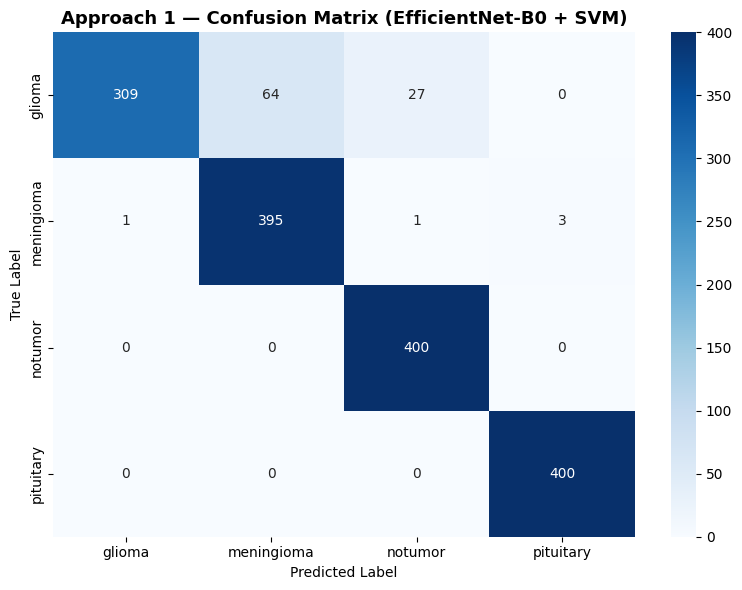

In [22]:
t0 = time.time()
y_pred_svm = svm.predict(X_test_scaled)
svm_infer_time = time.time() - t0

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')

print("=" * 55)
print("APPROACH 1 RESULTS — EfficientNet-B0 (Frozen) + SVM")
print("=" * 55)
print(f"  Accuracy          : {acc_svm*100:.2f}%")
print(f"  Weighted F1-Score : {f1_svm:.4f}")
print(f"  Inference time    : {svm_infer_time:.3f}s (full test set)")
print()
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Approach 1 — Confusion Matrix (EfficientNet-B0 + SVM)",
          fontsize=13, fontweight='bold')
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/cm_approach1_svm.png", dpi=150, bbox_inches='tight')
plt.show()

---
# 🟢 APPROACH 2 — EfficientNet-B0 End-to-End (v3 Improved)

> **v3 Improvements:**
> - Deeper head: `GAP → BN → Dense(512) → Dropout(0.5) → Dense(256) → Dropout(0.4) → Softmax`
> - Focal Loss with label smoothing=0.05
> - Cosine LR decay during fine-tuning
> - Gradient clipping (clipnorm=1.0)
> - 30 layers unfrozen for deeper MRI adaptation
> - Meningioma weight boosted ×1.5
> - Test-Time Augmentation (TTA) for final evaluation
---

### A2.1 — Build End-to-End Model (v3 Deeper Head)

In [23]:
def build_e2e_model_v3(num_classes, trainable_base=False):
    """
    v3 EfficientNet-B0 End-to-End Classifier.

    Changes vs v2:
      - Deeper head: Dense(512) → Dropout(0.5) → Dense(256) → Dropout(0.4)
        Better feature discrimination for glioma/meningioma boundary
      - L2 = 1e-4 (was 1e-5) — stronger regularisation
      - BatchNorm after GAP for stable activations
      - float32 output cast required for mixed precision compatibility
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = trainable_base

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)

    # --- v3: Deeper classification head ---
    x = Dense(
        512,
        activation='relu',
        kernel_regularizer=l2(L2_LAMBDA)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_1)(x)              # 0.50 — strong regularisation

    x = Dense(
        256,
        activation='relu',
        kernel_regularizer=l2(L2_LAMBDA)
    )(x)
    x = Dropout(DROPOUT_2)(x)              # 0.40

    # Cast to float32 for mixed precision compatibility
    x = Lambda(lambda t: tf.cast(t, tf.float32))(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=base.input, outputs=output,
                  name="EfficientNetB0_E2E_v3")
    return model, base


model_e2e, base_e2e = build_e2e_model_v3(NUM_CLASSES, trainable_base=False)

total_params     = model_e2e.count_params()
trainable_params = sum([K.count_params(w) for w in model_e2e.trainable_weights])
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,} (head only, base frozen)")

Total params     : 4,844,967
Trainable params : 791,812 (head only, base frozen)


In [12]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.0):

    cce = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=label_smoothing,
        reduction=tf.keras.losses.Reduction.NONE
    )

    def loss(y_true, y_pred):

        ce = cce(y_true, y_pred)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        focal_weight = alpha * tf.pow((1.0 - p_t), gamma)

        return tf.reduce_mean(focal_weight * ce)

    return loss

### A2.2 — Phase 1: Warm-Up Training (Frozen Base)

> With the deeper head (512→256), the warm-up phase is extended to **15 epochs**.
> This ensures the new layers are well-initialised before any backbone weights are touched.


In [24]:
# v3: Compile with Focal Loss + gradient clipping
model_e2e.compile(
    optimizer=Adam(LR_WARMUP, clipnorm=1.0),   # v3: gradient clipping
    # Change in both compile calls (warmup + finetune):
loss=focal_loss(gamma=2.0,
    alpha=0.35,
    label_smoothing=0.03),
    metrics=['accuracy']
)

callbacks_warmup = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1),
    ModelCheckpoint('/content/best_e2e_warmup.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("PHASE 1 — Warm-Up (frozen base, focal loss, LR=1e-3)")
print("-" * 60)

t0 = time.time()
history_warmup = model_e2e.fit(
    train_gen_aug,
    epochs=EPOCHS_WARMUP,
    validation_data=val_gen,
    callbacks=callbacks_warmup,
    class_weight=class_weight_dict,
    verbose=1
)
warmup_time = time.time() - t0
print(f"\nWarm-up completed in {warmup_time:.1f}s")

PHASE 1 — Warm-Up (frozen base, focal loss, LR=1e-3)
------------------------------------------------------------
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7346 - loss: 0.3471 - val_accuracy: 0.8545 - val_loss: 0.1810 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 138s 983ms/step - accuracy: 0.8154 - loss: 0.2471 - val_accuracy: 0.8741 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 994ms/step - accuracy: 0.8420 - loss: 0.2175 - val_accuracy: 0.9000 - val_loss: 0.1704 - learning_rate: 0.0010
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 998ms/step - accuracy: 0.8705 - loss: 0.1902 - val_accuracy: 0.9036 - val_loss: 0.1562 - learning_rate: 0.0010
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 137s 980ms/step - accuracy: 0.8634 - loss: 0.1768 - val_accuracy: 0.8973 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 141s 973ms/step - accuracy: 0.8839 - loss: 0.1639 - val_accuracy: 0.9

### A2.3 — Phase 2: Fine-Tuning (Unfreeze Top 30 Layers)

> **v3 Fine-Tuning Strategy:**
> - Unfreeze top **30** layers — deeper adaptation needed for MRI vs ImageNet features
> - LR = **2e-5** with cosine decay — prevents the oscillation seen with fixed LR
> - BatchNorm layers remain frozen to preserve learned statistics
> - Gradient clipping (clipnorm=1.0) prevents loss spikes


In [25]:
# Unfreeze top 30 layers
base_e2e.trainable = True
# In Phase 2 fine-tuning cell:
FINE_TUNE_FROM = len(base_e2e.layers) - 120  # was 30
for layer in base_e2e.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# Keep BatchNorm layers frozen to preserve learned statistics
# (catastrophic forgetting prevention)
for layer in base_e2e.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# v3: Cosine decay LR schedule — smoother convergence than fixed LR
steps_per_epoch = len(train_gen_aug)
total_steps = EPOCHS_FINETUNE * steps_per_epoch

cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FINETUNE,
    decay_steps=total_steps,
    alpha=1e-7          # minimum LR floor
)

# v3: Compile with focal loss + cosine decay + gradient clipping
model_e2e.compile(
    optimizer=Adam(cosine_decay, clipnorm=1.0),
    # Change in both compile calls (warmup + finetune):
  loss=focal_loss(gamma=2.0,
    alpha=0.35,
    label_smoothing=0.03),
    metrics=['accuracy']
)

trainable_count = sum(1 for l in model_e2e.layers if l.trainable)
print(f"Trainable layers for fine-tuning : {trainable_count}")
print(f"Fine-tuning from layer           : {FINE_TUNE_FROM} / {len(base_e2e.layers)}")
print(f"LR schedule                      : CosineDecay {LR_FINETUNE} → ~0")

callbacks_finetune = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_e2e_finetune.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0)
    # NOTE: No ReduceLROnPlateau — cosine schedule handles LR decay
]

print("\nPHASE 2 — Fine-Tuning (30 layers, cosine LR, focal loss)")
print("-" * 60)

t0 = time.time()
history_ft = model_e2e.fit(
    train_gen_aug,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_finetune,
    class_weight=class_weight_dict,
    verbose=1
)
e2e_train_time = time.time() - t0
print(f"\nFine-tuning completed in {e2e_train_time:.1f}s")

Trainable layers for fine-tuning : 104
Fine-tuning from layer           : 118 / 238
LR schedule                      : CosineDecay 1e-05 → ~0

PHASE 2 — Fine-Tuning (30 layers, cosine LR, focal loss)
------------------------------------------------------------
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9254 - loss: 0.1018 - val_accuracy: 0.9375 - val_loss: 0.0953
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9344 - loss: 0.0983 - val_accuracy: 0.9446 - val_loss: 0.0950
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9453 - loss: 0.0935 - val_accuracy: 0.9536 - val_loss: 0.0935
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9475 - loss: 0.0938 - val_accuracy: 0.9491 - val_loss: 0.0913
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9484 - loss: 0.0928 - val_accuracy: 0.9491 - val_loss: 0.0917
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9511 - loss: 0.0920 - val_a

### A2.4 — Training Curves

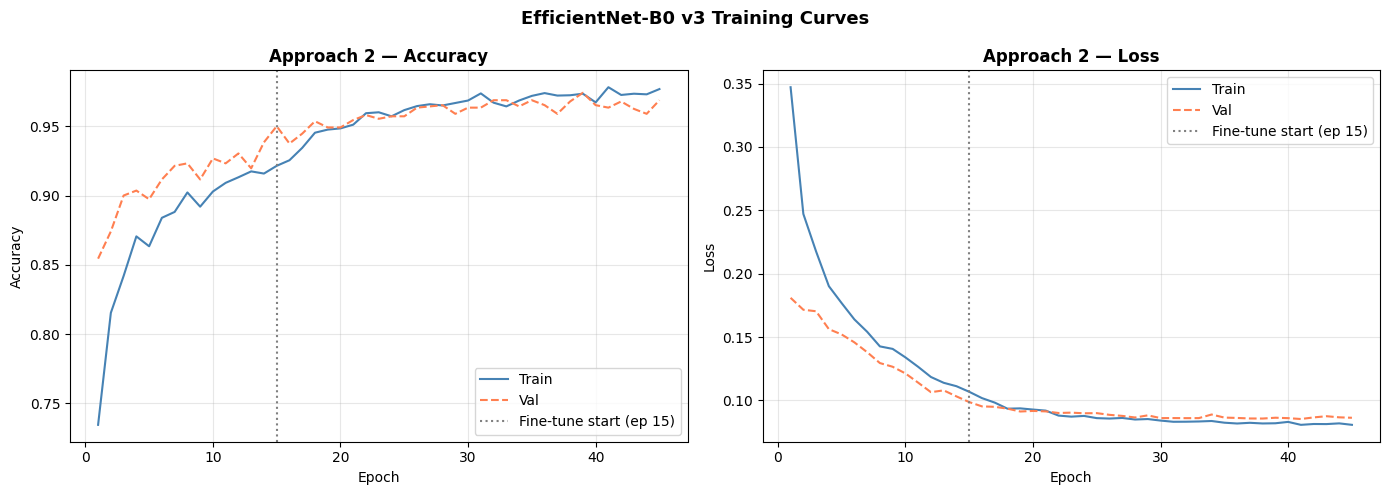

In [26]:
def merge_history(h1, h2):
    merged = {}

    all_keys = set(h1.history.keys()).union(set(h2.history.keys()))

    for key in all_keys:
        v1 = h1.history.get(key, [])
        v2 = h2.history.get(key, [])
        merged[key] = v1 + v2

    return merged

hist = merge_history(history_warmup, history_ft)
ep   = range(1, len(hist['accuracy']) + 1)
warmup_end = len(history_warmup.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (ax1, 'accuracy', 'Approach 2 — Accuracy'),
    (ax2, 'loss',     'Approach 2 — Loss')
]:
    ax.plot(ep, hist[metric],          label=f'Train', color='steelblue')
    ax.plot(ep, hist[f'val_{metric}'], label=f'Val',   color='coral', linestyle='--')
    ax.axvline(x=warmup_end, color='gray', linestyle=':',
               label=f'Fine-tune start (ep {warmup_end})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("EfficientNet-B0 v3 Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/training_curves_v3.png", dpi=150, bbox_inches='tight')
plt.show()

### A2.5 — Evaluate Approach 2: Standard Inference

> Test set is evaluated here for the first time.


50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step
APPROACH 2 RESULTS — EfficientNet-B0 E2E (v3)
  Accuracy          : 92.19%
  Weighted F1-Score : 0.9204
  Inference time    : 26.271s

              precision    recall  f1-score   support

      glioma       0.97      0.78      0.86       400
  meningioma       0.84      0.92      0.88       400
     notumor       0.95      0.99      0.97       400
   pituitary       0.94      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



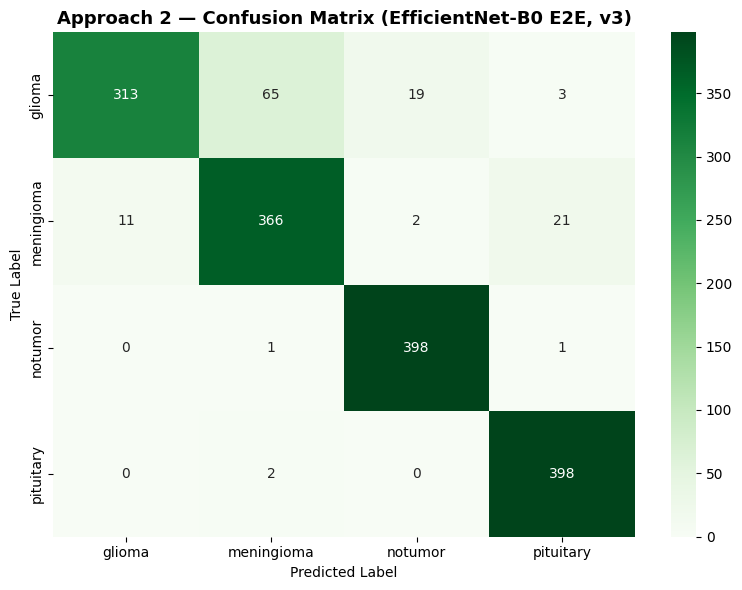

In [27]:
test_gen.reset()
t0 = time.time()
y_pred_proba_e2e = model_e2e.predict(test_gen, verbose=1)
e2e_infer_time   = time.time() - t0

y_pred_e2e = np.argmax(y_pred_proba_e2e, axis=1)
y_true_e2e = test_gen.classes

acc_e2e = accuracy_score(y_true_e2e, y_pred_e2e)
f1_e2e  = f1_score(y_true_e2e, y_pred_e2e, average='weighted')

print("=" * 60)
print("APPROACH 2 RESULTS — EfficientNet-B0 E2E (v3)")
print("=" * 60)
print(f"  Accuracy          : {acc_e2e*100:.2f}%")
print(f"  Weighted F1-Score : {f1_e2e:.4f}")
print(f"  Inference time    : {e2e_infer_time:.3f}s")
print()
print(classification_report(y_true_e2e, y_pred_e2e, target_names=CLASS_NAMES))

cm_e2e = confusion_matrix(y_true_e2e, y_pred_e2e)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_e2e, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Approach 2 — Confusion Matrix (EfficientNet-B0 E2E, v3)",
          fontsize=13, fontweight='bold')
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/cm_approach2_v3.png", dpi=150, bbox_inches='tight')
plt.show()

### A2.6 — Test-Time Augmentation (TTA)

> **v3: TTA** averages predictions over **N=5** lightly augmented versions of each test image.
> This reduces variance in the final prediction and typically adds **0.5–2%** accuracy,
> especially for the hard glioma/meningioma cases near the decision boundary.


Running TTA (5 augmented passes + 1 standard pass × 2 weight) ...
Found 1600 images belonging to 4 classes.
  TTA pass 1/5 done
  TTA pass 2/5 done
  TTA pass 3/5 done
  TTA pass 4/5 done
  TTA pass 5/5 done

TTA inference completed in 184.7s
APPROACH 2 TTA RESULTS
  Accuracy (TTA)    : 93.12%
  Weighted F1 (TTA) : 0.9295
  Gain vs standard  : +0.94%

              precision    recall  f1-score   support

      glioma       0.98      0.78      0.87       400
  meningioma       0.86      0.95      0.90       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



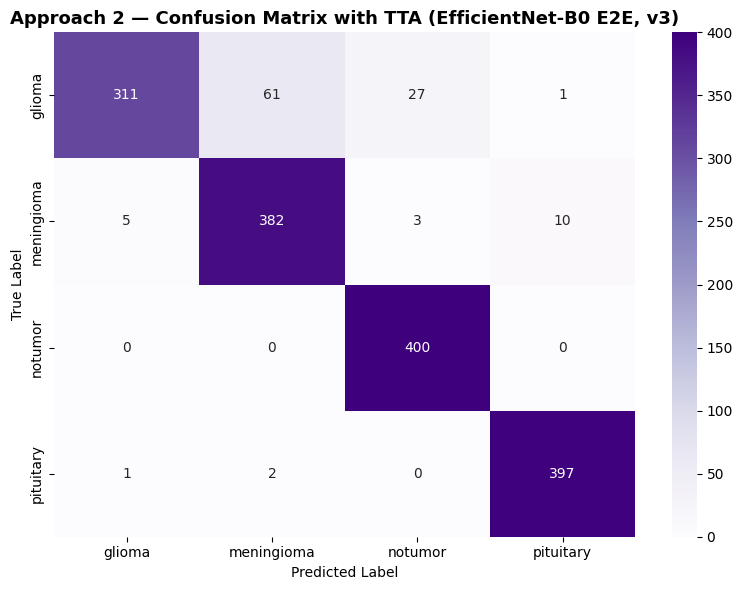

In [28]:
TTA_STEPS = 5

def predict_with_tta(model, test_dir, class_names, img_size, batch_size, n_tta=5):
    """
    Run TTA: average predictions from N augmented passes over the test set.
    """
    tta_preds = None
    tta_gen = tta_datagen.flow_from_directory(
        test_dir_clahe,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    for i in range(n_tta):
        tta_gen.reset()
        preds = model.predict(tta_gen, verbose=0)
        if tta_preds is None:
            tta_preds = preds
        else:
            tta_preds += preds
        print(f"  TTA pass {i+1}/{n_tta} done")

    # Also add one standard (CLAHE only) pass with higher weight
    test_gen.reset()
    std_preds = model.predict(test_gen, verbose=0)
    tta_preds += std_preds * 2          # standard pass weighted ×2

    tta_preds /= (n_tta + 2)            # normalise
    return tta_preds


print(f"Running TTA ({TTA_STEPS} augmented passes + 1 standard pass × 2 weight) ...")
t0 = time.time()
y_pred_proba_tta = predict_with_tta(
    model_e2e, test_dir, CLASS_NAMES, IMG_SIZE, BATCH_SIZE, TTA_STEPS
)
tta_time = time.time() - t0

y_pred_tta = np.argmax(y_pred_proba_tta, axis=1)
acc_tta = accuracy_score(y_true_e2e, y_pred_tta)
f1_tta  = f1_score(y_true_e2e, y_pred_tta, average='weighted')

print(f"\nTTA inference completed in {tta_time:.1f}s")
print("=" * 60)
print("APPROACH 2 TTA RESULTS")
print("=" * 60)
print(f"  Accuracy (TTA)    : {acc_tta*100:.2f}%")
print(f"  Weighted F1 (TTA) : {f1_tta:.4f}")
print(f"  Gain vs standard  : +{(acc_tta - acc_e2e)*100:.2f}%")
print()
print(classification_report(y_true_e2e, y_pred_tta, target_names=CLASS_NAMES))

cm_tta = confusion_matrix(y_true_e2e, y_pred_tta)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Approach 2 — Confusion Matrix with TTA (EfficientNet-B0 E2E, v3)",
          fontsize=13, fontweight='bold')
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/cm_approach2_tta.png", dpi=150, bbox_inches='tight')
plt.show()

---
# 📊 Step 6 — Head-to-Head Comparison
---

In [29]:
import pandas as pd

results = {
    "Approach 1\n(EfficientNetB0 + SVM)": {
        "Accuracy (%)": round(acc_svm * 100, 2),
        "F1-Score":     round(f1_svm, 4),
        "Train Time (s)": round(svm_train_time, 2),
        "Infer Time (s)": round(svm_infer_time, 3)
    },
    "Approach 2\n(E2E Standard)": {
        "Accuracy (%)": round(acc_e2e * 100, 2),
        "F1-Score":     round(f1_e2e, 4),
        "Train Time (s)": round(e2e_train_time, 2),
        "Infer Time (s)": round(e2e_infer_time, 3)
    },
    "Approach 2\n(E2E + TTA)": {
        "Accuracy (%)": round(acc_tta * 100, 2),
        "F1-Score":     round(f1_tta, 4),
        "Train Time (s)": round(e2e_train_time, 2),
        "Infer Time (s)": round(tta_time, 3)
    }
}

df_results = pd.DataFrame(results).T
print("\n" + "=" * 65)
print("           FINAL COMPARISON SUMMARY (v3)")
print("=" * 65)
print(df_results.to_string())
print("=" * 65)

winner = max(results, key=lambda k: results[k]['Accuracy (%)'])
print(f"\n🏆 Best Accuracy : {winner.strip()}")


           FINAL COMPARISON SUMMARY (v3)
                                    Accuracy (%)  F1-Score  Train Time (s)  Infer Time (s)
Approach 1\n(EfficientNetB0 + SVM)         94.00    0.9381           46.38           4.458
Approach 2\n(E2E Standard)                 92.19    0.9204         4582.66          26.271
Approach 2\n(E2E + TTA)                    93.12    0.9295         4582.66         184.734

🏆 Best Accuracy : Approach 1
(EfficientNetB0 + SVM)


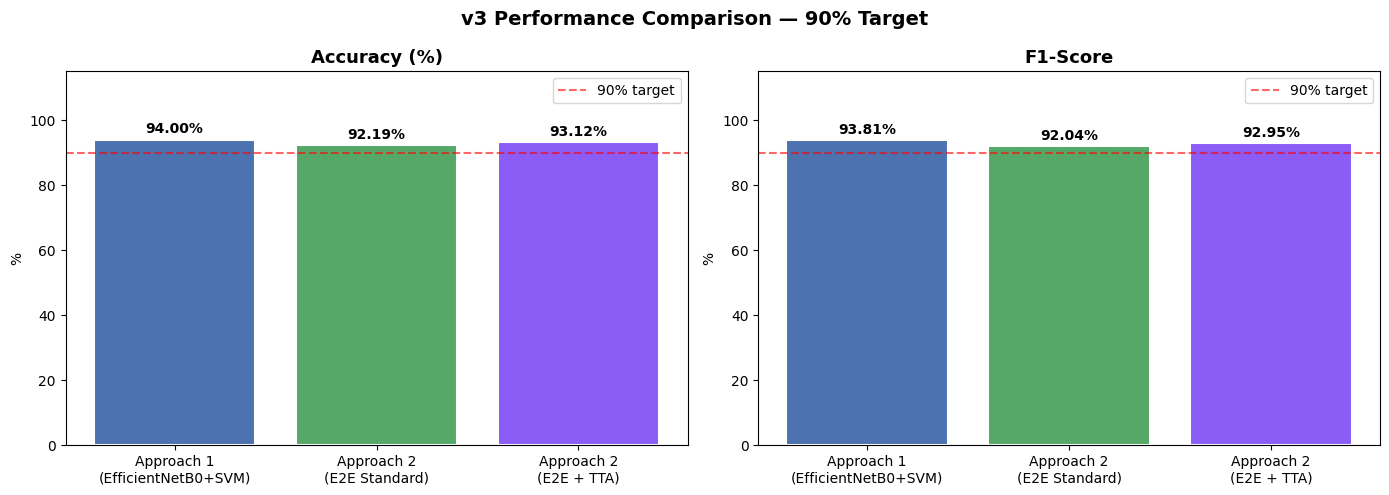

In [30]:
metrics = ['Accuracy (%)', 'F1-Score']
labels  = [
    'Approach 1\n(EfficientNetB0+SVM)',
    'Approach 2\n(E2E Standard)',
    'Approach 2\n(E2E + TTA)'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    vals = [results[k][metric] for k in results]
    scale = 100 if metric == 'F1-Score' else 1
    disp  = [v * scale if metric == 'F1-Score' else v for v in vals]
    colors = ['#4C72B0', '#55A868', '#8B5CF6']
    bars = ax.bar(labels, disp, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel("%")
    ax.set_ylim(0, 115)
    ax.axhline(y=90, color='red', linestyle='--', alpha=0.6, label='90% target')
    ax.legend()
    for bar, val in zip(bars, disp):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{val:.2f}%",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("v3 Performance Comparison — 90% Target", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/comparison_chart_v3.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Step 7 — Per-Class Analysis

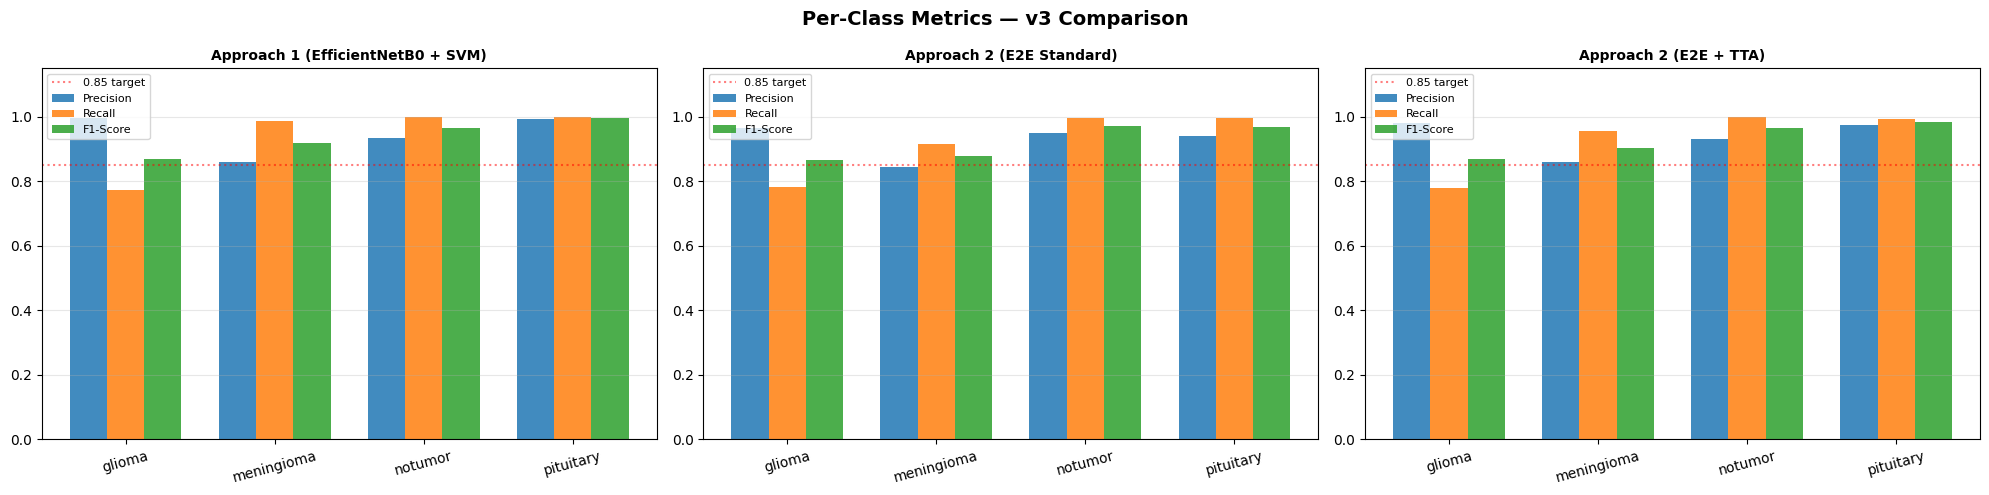

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (title, y_true, y_pred) in zip(axes, [
    ("Approach 1 (EfficientNetB0 + SVM)",  y_test,     y_pred_svm),
    ("Approach 2 (E2E Standard)",           y_true_e2e, y_pred_e2e),
    ("Approach 2 (E2E + TTA)",              y_true_e2e, y_pred_tta)
]):
    prec = precision_score(y_true, y_pred, average=None)
    rec  = recall_score(y_true, y_pred, average=None)
    f1   = f1_score(y_true, y_pred, average=None)
    x    = np.arange(len(CLASS_NAMES))
    w    = 0.25
    ax.bar(x - w, prec, w, label='Precision', alpha=0.85)
    ax.bar(x,     rec,  w, label='Recall',    alpha=0.85)
    ax.bar(x + w, f1,   w, label='F1-Score',  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.axhline(y=0.85, color='red', linestyle=':', alpha=0.5, label='0.85 target')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Per-Class Metrics — v3 Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/per_class_metrics_v3.png", dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Step 7b — Glioma vs Meningioma Deep-Dive

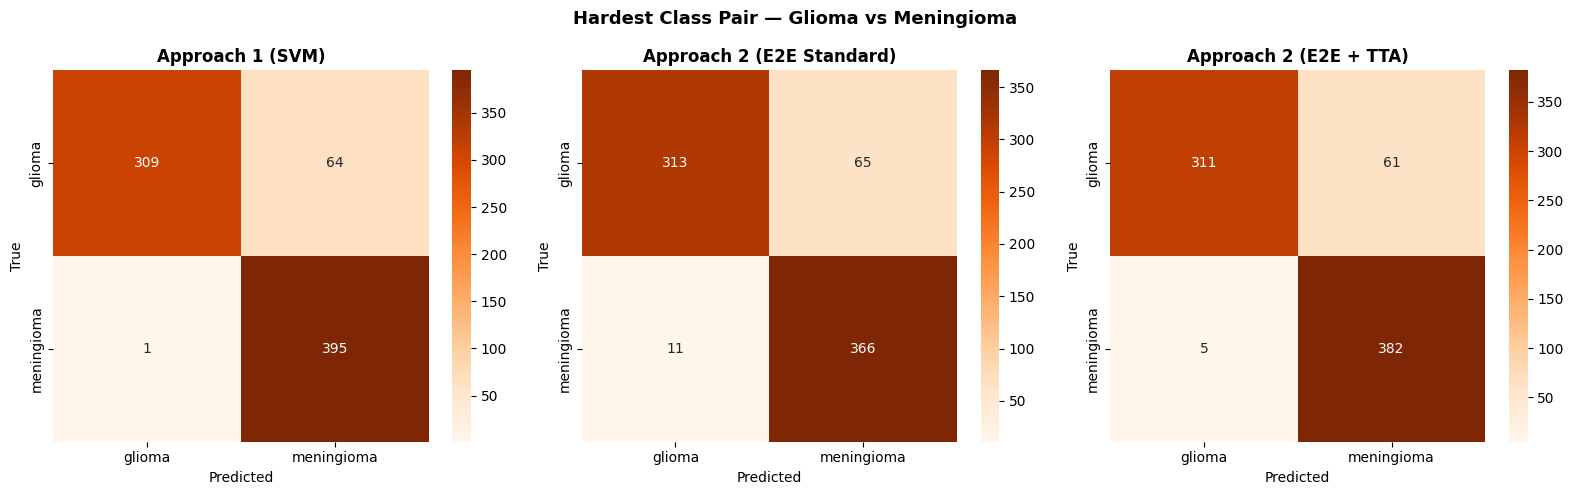

In [32]:
glioma_idx     = CLASS_NAMES.index('glioma')     if 'glioma'     in CLASS_NAMES else None
meningioma_idx = CLASS_NAMES.index('meningioma') if 'meningioma' in CLASS_NAMES else None

if glioma_idx is not None and meningioma_idx is not None:
    hard_classes = [glioma_idx, meningioma_idx]
    hard_names   = ['glioma', 'meningioma']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (title, y_true, y_pred) in zip(axes, [
        ("Approach 1 (SVM)",           y_test,     y_pred_svm),
        ("Approach 2 (E2E Standard)",  y_true_e2e, y_pred_e2e),
        ("Approach 2 (E2E + TTA)",     y_true_e2e, y_pred_tta)
    ]):
        mask = np.isin(y_true, hard_classes)
        cm_hard = confusion_matrix(y_true[mask], y_pred[mask], labels=hard_classes)
        sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Oranges',
                    xticklabels=hard_names, yticklabels=hard_names, ax=ax)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel("True"); ax.set_xlabel("Predicted")

    plt.suptitle("Hardest Class Pair — Glioma vs Meningioma",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/content/hard_class_confusion_v3.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Glioma/meningioma not found — check CLASS_NAMES:", CLASS_NAMES)

## 💾 Step 8 — Save Model & Results

In [33]:
import joblib

joblib.dump(svm,    '/content/drive/MyDrive/svm_efficientnetb0_v3.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/scaler_efficientnetb0_v3.pkl')
print("SVM model saved.")

model_e2e.save('/content/drive/MyDrive/efficientnetb0_e2e_v3.keras')
print("End-to-end model saved.")

df_results.to_csv('/content/drive/MyDrive/comparison_results_v3.csv')
print("Results CSV saved.")

print("\n✅ All artefacts saved to Google Drive.")

SVM model saved.
End-to-end model saved.
Results CSV saved.

✅ All artefacts saved to Google Drive.


In [45]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install -q reportlab seaborn

# ============================================================
# IMPORTS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Preformatted, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors

# ============================================================
# CREATE RESULTS DIRECTORY
# ============================================================
results_dir = "final_project_results"
os.makedirs(results_dir, exist_ok=True)

# ============================================================
# SAVE ALL COMPARISON FIGURES
# ============================================================
# Move existing generated plots to results folder for PDF inclusion
import shutil
plot_map = {
    "/content/comparison_chart_v3.png": "comparison_chart.png",
    "/content/cm_approach1_svm.png": "cm_svm.png",
    "/content/cm_approach2_v3.png": "cm_e2e.png",
    "/content/cm_approach2_tta.png": "cm_tta.png",
    "/content/per_class_metrics_v3.png": "per_class.png"
}

for src, dst in plot_map.items():
    if os.path.exists(src):
        shutil.copy(src, os.path.join(results_dir, dst))

# ============================================================
# GENERATE CONSOLIDATED TEXT REPORT
# ============================================================
report_txt_path = os.path.join(results_dir, "full_project_summary.txt")
with open(report_txt_path, "w") as f:
    f.write("BRAIN MRI TUMOR CLASSIFICATION - PROJECT SUMMARY (v3)\n")
    f.write("=" * 60 + "\n\n")
    f.write("### 1. MODEL COMPARISON ###\n")
    f.write(df_results.to_string() + "\n\n")
    f.write("### 2. DETAILED REPORTS ###\n\n")
    f.write("--- Approach 1 (SVM) ---\n")
    f.write(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES) + "\n")
    f.write("--- Approach 2 (E2E Standard) ---\n")
    f.write(classification_report(y_true_e2e, y_pred_e2e, target_names=CLASS_NAMES) + "\n")
    f.write("--- Approach 2 (E2E + TTA) ---\n")
    f.write(classification_report(y_true_e2e, y_pred_tta, target_names=CLASS_NAMES) + "\n")

# ============================================================
# CREATE COMPREHENSIVE PDF REPORT
# ============================================================
pdf_path = os.path.join(results_dir, "Brain_MRI_Final_Project_Report.pdf")
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("<b>Brain MRI Tumor Classification Final Report</b>", styles['Title']))
elements.append(Spacer(1, 12))

# Comparison Table
elements.append(Paragraph("<b>1. Overall Performance Comparison</b>", styles['Heading2']))
data = [["Approach", "Accuracy", "F1-Score", "Inf. Time (s)"]] + \
       [[idx, f"{row['Accuracy (%)']:.2f}%", f"{row['F1-Score']:.4f}", f"{row['Infer Time (s)']:.3f}"]
        for idx, row in df_results.iterrows()]
table = Table(data, hAlign='LEFT')
table.setStyle(TableStyle([('BACKGROUND', (0,0), (-1,0), colors.grey), ('TEXTCOLOR',(0,0),(-1,0),colors.whitesmoke), ('GRID', (0,0), (-1,-1), 1, colors.black)]))
elements.append(table)
elements.append(Spacer(1, 20))

# Summary Chart
if os.path.exists(os.path.join(results_dir, "comparison_chart.png")):
    elements.append(Paragraph("<b>2. Performance Metrics Visualization</b>", styles['Heading2']))
    elements.append(Image(os.path.join(results_dir, "comparison_chart.png"), width=450, height=180))
elements.append(Spacer(1, 20))

# Confusion Matrices
elements.append(Paragraph("<b>3. Confusion Matrices</b>", styles['Heading2']))
for title, img_name in [("SVM Confusion Matrix", "cm_svm.png"),
                        ("E2E Standard Confusion Matrix", "cm_e2e.png"),
                        ("E2E + TTA Confusion Matrix", "cm_tta.png")]:
    img_p = os.path.join(results_dir, img_name)
    if os.path.exists(img_p):
        elements.append(Paragraph(f"<i>{title}</i>", styles['BodyText']))
        elements.append(Image(img_p, width=350, height=250))
        elements.append(Spacer(1, 10))

doc.build(elements)

print("=" * 60)
print(f"SUCCESS: Comprehensive results saved to: {results_dir}")
print(f"PDF Report: {pdf_path}")
print("=" * 60)

try:
    from google.colab import files
    files.download(pdf_path)
    files.download(report_txt_path)
except:
    pass

SUCCESS: Comprehensive results saved to: final_project_results
PDF Report: final_project_results/Brain_MRI_Final_Project_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 📉 Training Loss and Confusion Matrices
Below we visualize the model's convergence and its final classification performance across all approaches.

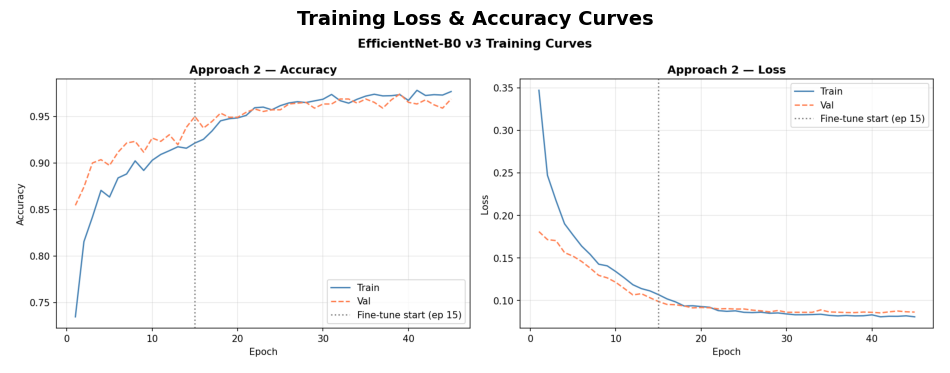

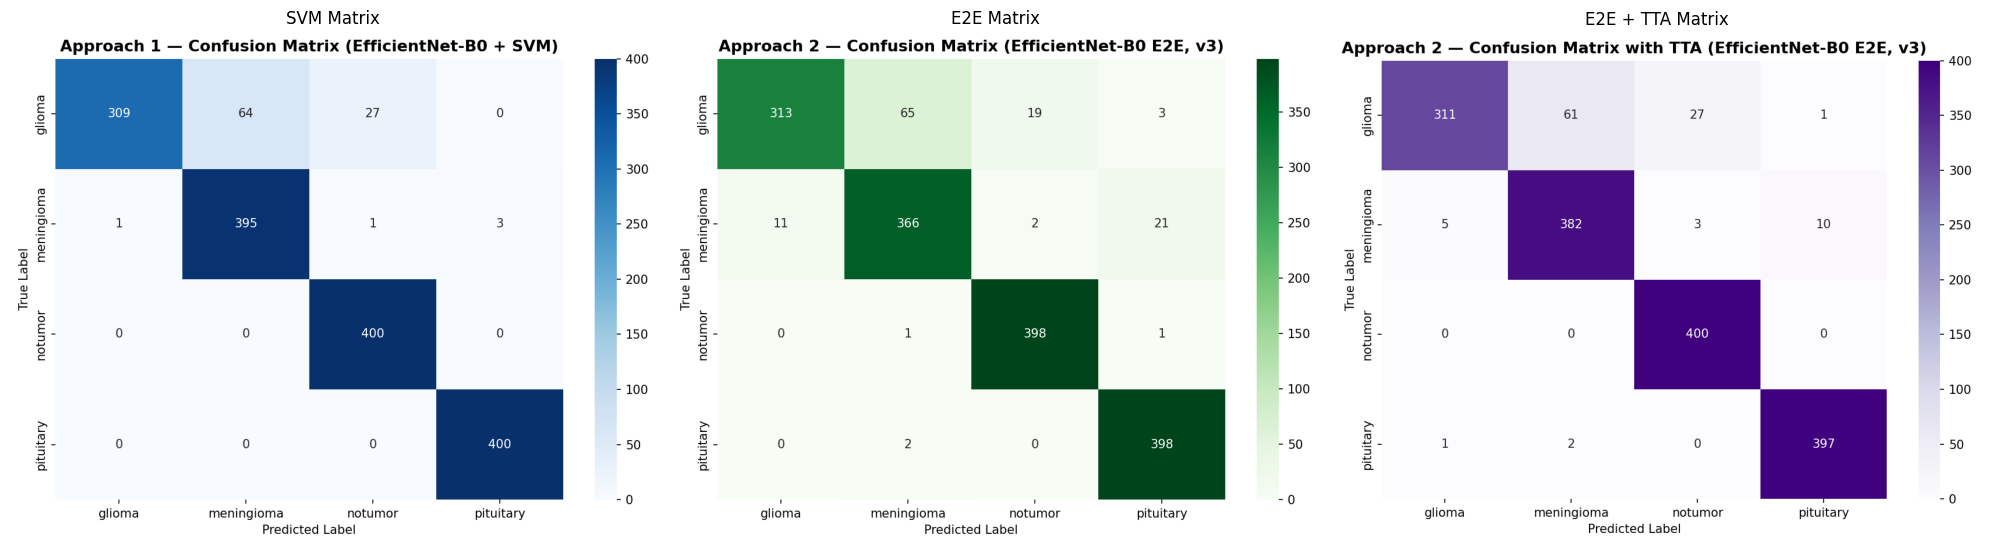

In [46]:
import matplotlib.image as mpimg

# 1. Show Training Curves
if os.path.exists('/content/training_curves_v3.png'):
    plt.figure(figsize=(12, 6))
    img = mpimg.imread('/content/training_curves_v3.png')
    plt.imshow(img)
    plt.title("Training Loss & Accuracy Curves", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# 2. Show Matrices Side-by-Side
plots = [
    ("/content/cm_approach1_svm.png", "SVM Matrix"),
    ("/content/cm_approach2_v3.png", "E2E Matrix"),
    ("/content/cm_approach2_tta.png", "E2E + TTA Matrix")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (path, title) in enumerate(plots):
    if os.path.exists(path):
        img = mpimg.imread(path)
        axes[i].imshow(img)
        axes[i].set_title(title)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'File not found:\n{title}', ha='center')
        axes[i].axis('off')
plt.tight_layout()
plt.show()

### 📂 Consolidate and Download All Results
This cell gathers all plots, reports, and CSV data into the `final_project_results` folder and creates a zip file for download.

In [47]:
import shutil
from google.colab import files

# Ensure directory exists
results_dir = "final_project_results"
os.makedirs(results_dir, exist_ok=True)

# List of all files to include
files_to_copy = [
    "/content/training_curves_v3.png",
    "/content/cm_approach1_svm.png",
    "/content/cm_approach2_v3.png",
    "/content/cm_approach2_tta.png",
    "/content/comparison_chart_v3.png",
    "/content/per_class_metrics_v3.png",
    "/content/hard_class_confusion_v3.png",
    "/content/eda_distribution.png",
    "/content/eda_samples.png"
]

for src in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(results_dir, os.path.basename(src)))

# Save the results table as CSV in the folder
df_results.to_csv(os.path.join(results_dir, "performance_summary.csv"))

# Create a ZIP archive
shutil.make_archive("Brain_MRI_Project_Final", 'zip', results_dir)

print(f"✅ All artifacts consolidated in {results_dir}")
files.download("Brain_MRI_Project_Final.zip")

✅ All artifacts consolidated in final_project_results


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>